# 💊 Drug-Drug Interaction Risk Classifier
## Notebook 01 — Data Loading & Exploratory Data Analysis

**Project:** Nigeria-Focused DDI Risk Classification  
**Author:** Ahmed  
**Data Sources (Google Drive):**
- `TWOSIDES.pt` — PyTDC-cached TWOSIDES dataset (4.6M drug-pair records)
- `nafdac_ingredients.csv` — Full NAFDAC Greenbook ingredient list
- `nafdac_individual_drugs.csv` — Individual generic names (combos split)

---
### Notebook Outline
1. Install & Import
2. Mount Google Drive & Locate Files
3. Load TWOSIDES.pt
4. Load NAFDAC CSVs & Build Nigerian Drug Universe
5. Filter TWOSIDES → Nigerian Drug Pairs
6. Fetch PubChem Molecular Descriptors
7. CYP Enzyme & Pharmacological Feature Table
8. Build Final Feature Dataset
9. EDA — 7 Visualisations
10. Save to Drive

---
## 1. Install & Import

In [1]:
!pip install -q requests beautifulsoup4 lxml tqdm plotly

In [2]:
import os, re, time, warnings
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import requests
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

SEV_MAP    = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}
SEV_ORDER  = ['None', 'Mild', 'Moderate', 'Severe']
SEV_COLORS = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

print('✅ All imports ready.')

✅ All imports ready.


In [3]:
!pip install PyTDC

---
## 2. Mount Google Drive & Locate Files

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
def find_file(root, filename):
    for dirpath, dirs, files in os.walk(root):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

DRIVE_ROOT = '/content/drive/MyDrive/DDI project '

print('Searching Google Drive for NAFDAC files...')
PATH_NAFDAC_1 = find_file(DRIVE_ROOT, 'nafdac_ingredients.csv')
PATH_NAFDAC_2 = find_file(DRIVE_ROOT, 'nafdac_individual_drugs.csv')

print(f'  nafdac_ingredients.csv  : {PATH_NAFDAC_1 or "NOT FOUND"}')
print(f'  nafdac_individual_drugs : {PATH_NAFDAC_2 or "NOT FOUND"}')

# Manual override if auto-find fails:
# PATH_NAFDAC_1 = '/content/drive/MyDrive/YOUR_FOLDER/nafdac_ingredients.csv'
# PATH_NAFDAC_2 = '/content/drive/MyDrive/YOUR_FOLDER/nafdac_individual_drugs.csv'

missing = [n for n,p in [('nafdac_ingredients.csv',PATH_NAFDAC_1),
                          ('nafdac_individual_drugs.csv',PATH_NAFDAC_2)] if p is None]
if missing:
    raise FileNotFoundError(f'Files not found: {missing}. Set paths manually above.')

SAVE_FOLDER = os.path.dirname(PATH_NAFDAC_1)
print(f'\nFiles found. Outputs will save to: {SAVE_FOLDER}')

Searching Google Drive for NAFDAC files...
  nafdac_ingredients.csv  : /content/drive/MyDrive/DDI project /nafdac_ingredients.csv
  nafdac_individual_drugs : /content/drive/MyDrive/DDI project /nafdac_individual_drugs.csv

Files found. Outputs will save to: /content/drive/MyDrive/DDI project 


In [6]:
from tdc.multi_pred import DDI

print('Loading TWOSIDES via PyTDC...')
print('First run downloads ~200MB and caches it — subsequent runs are instant.\n')

tdc_data     = DDI(name='TWOSIDES')
twosides_raw = tdc_data.get_data()

print(f'\nTWOSIDES loaded!')
print(f'  Shape   : {twosides_raw.shape}')
print(f'  Columns : {list(twosides_raw.columns)}')
print(f'  Records : {len(twosides_raw):,}')
twosides_raw.head(5)

Downloading...


Loading TWOSIDES via PyTDC...
First run downloads ~200MB and caches it — subsequent runs are instant.



100%|██████████| 677M/677M [00:16<00:00, 40.9MiB/s]
Loading...
Done!



TWOSIDES loaded!
  Shape   : (4649441, 5)
  Columns : ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']
  Records : 4,649,441


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,1024
1,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,767
2,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,79
3,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,25
4,CID000002173,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=CC=C3)N)C(=O...,CID000003345,CCC(=O)N(C1CCN(CC1)CCC2=CC=CC=C2)C3=CC=CC=C3,85


In [7]:
# Standardise column names regardless of PyTDC version
rename = {}
for c in twosides_raw.columns:
    cl = c.lower().replace(' ','_')
    if cl in ('drug1_id','drug1id'):          rename[c] = 'Drug1_ID'
    elif cl in ('drug2_id','drug2id'):        rename[c] = 'Drug2_ID'
    elif cl in ('drug1','smiles1','drug_1'):  rename[c] = 'Drug1'
    elif cl in ('drug2','smiles2','drug_2'):  rename[c] = 'Drug2'
    elif cl in ('y','label','side_effect','type','interaction','index'): rename[c] = 'Y'

twosides_raw = twosides_raw.rename(columns=rename)
print('Columns after standardisation:', list(twosides_raw.columns))
assert 'Y' in twosides_raw.columns, f'Y column missing. Columns: {list(twosides_raw.columns)}'

sample = str(twosides_raw['Drug1'].iloc[0]) if 'Drug1' in twosides_raw.columns else ''
IS_SMILES = any(c in sample for c in ['(',')',  '=','#','[',']'])
print(f'Drug1 format : {"SMILES" if IS_SMILES else "drug names"}')
print(f'Y unique     : {twosides_raw["Y"].nunique():,} side effect types')

Columns after standardisation: ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']
Drug1 format : SMILES
Y unique     : 1,317 side effect types


In [8]:
# Load side effect label names and map Y -> severity 0-3
from tdc.utils import get_label_map

label_map = {}
try:
    label_map = get_label_map(name='TWOSIDES', task='DDI', name_column='Side Effect Name')
    print(f'Label map loaded: {len(label_map):,} side effects')
    for k,v in list(label_map.items())[:6]: print(f'  Y={k} -> {v}')
except Exception as e:
    print(f'Label map unavailable ({e}) -- classifying from Y integer value ranges')

SEVERE_KW   = ['death','cardiac arrest','anaphyla','respiratory failure','haemorrhage',
               'hemorrhage','rhabdomyolysis','liver failure','renal failure','sepsis',
               'stroke','myocardial infarction','ventricular fibrillation','coma']
MODERATE_KW = ['arrhythmia','hypotension','bleeding','thrombocytopenia','agranulocytosis',
               'hepatitis','nephrotoxicity','pancreatitis','hypertension','hyperglycaemia',
               'hypoglycaemia','convulsion','seizure','oedema','edema','syncope','anaemia']
MILD_KW     = ['nausea','vomiting','diarrhea','diarrhoea','headache','dizziness','rash',
               'pruritus','fatigue','insomnia','constipation','abdominal pain','myalgia']

def y_to_severity(y_val):
    if label_map:
        try: name = str(label_map.get(int(y_val), str(y_val))).lower()
        except: name = str(y_val).lower()
    else:
        name = str(y_val).lower()
    if any(k in name for k in SEVERE_KW):   return 3
    if any(k in name for k in MODERATE_KW): return 2
    if any(k in name for k in MILD_KW):     return 1
    return 0

print('\nMapping Y labels to severity classes...')
twosides_raw['severity']       = twosides_raw['Y'].apply(y_to_severity)
twosides_raw['severity_label'] = twosides_raw['severity'].map(SEV_MAP)
print('Severity distribution across all TWOSIDES:')
print(twosides_raw['severity_label'].value_counts())

Label map loaded: 1,317 side effects
  Y=1024 -> hypermagnesemia
  Y=767 -> retinopathy of prematurity
  Y=79 -> atelectasis
  Y=25 -> alkalosis
  Y=85 -> Back Ache
  Y=735 -> lung edema

Mapping Y labels to severity classes...
Severity distribution across all TWOSIDES:
severity_label
None        4109569
Moderate     285201
Mild         157451
Severe        97220
Name: count, dtype: int64


---
## 3. Load TWOSIDES.pt

The `.pt` file is a PyTorch-serialised object cached by PyTDC.  
It contains drug pairs with columns: `Drug1_ID`, `Drug1` (SMILES), `Drug2_ID`, `Drug2` (SMILES), `Y` (side effect label integer).

This cell is removed because its purpose (loading `TWOSIDES.pt` via `torch.load`) conflicts with the primary and correct method of loading the TWOSIDES dataset using PyTDC's `DDI` class in a previous cell (`zvm8jipvpiEc`). The `.pt` file it attempts to load (`twoside_random_s0.pt`) was found to not contain the raw DDI data in the expected format, leading to inconsistencies and errors in subsequent processing steps. By removing this cell, we ensure that `twosides_raw` retains the correct data loaded by PyTDC.

In [9]:
nafdac_full = pd.read_csv(PATH_NAFDAC_1)
nafdac_ind  = pd.read_csv(PATH_NAFDAC_2)

print(f'nafdac_ingredients.csv      : {nafdac_full.shape} | cols: {list(nafdac_full.columns)}')
print(f'nafdac_individual_drugs.csv : {nafdac_ind.shape}  | cols: {list(nafdac_ind.columns)}')

name_col = next((c for c in ['generic_name_lower','generic_name',
                              'ingredient_name_clean','ingredient_name']
                 if c in nafdac_ind.columns), nafdac_ind.columns[0])

nafdac_scraped = (
    nafdac_ind[name_col].dropna()
    .str.lower().str.strip().unique().tolist()
)
print(f'\nUnique generic drugs from NAFDAC scrape: {len(nafdac_scraped):,}')
nafdac_ind.head(8)

nafdac_ingredients.csv      : (2221, 8) | cols: ['ingredient_name', 'ingredient_id', 'nafdac_url', 'page_scraped', 'ingredient_name_clean', 'is_combination', 'component_count', 'components']
nafdac_individual_drugs.csv : (1775, 6)  | cols: ['generic_name', 'generic_name_lower', 'source_ingredient', 'ingredient_id', 'is_combination', 'nafdac_url']

Unique generic drugs from NAFDAC scrape: 1,775


,generic_name,generic_name_lower,source_ingredient,ingredient_id,is_combination,nafdac_url
0,& 18) L1 protein vaccine,& 18) l1 protein vaccine,"Human papillomavirus quadrivalent (types 6, 11...",1761,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
1,10 CCID50 Neomycin 15mcg Stabilizer 1M MgCL2,10 ccid50 neomycin 15mcg stabilizer 1m mgcl2,Polio virus grown on primary monkey kidney cul...,1763,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
2,10 CCID50 Type 111&gt,10 ccid50 type 111&gt,Polio virus grown on primary monkey kidney cul...,1763,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
3,17D-204 strain (live,17d-204 strain (live,"Yellow fever virus1, 17D-204 strain (live, att...",1774,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
4,18C,18c,Pneumococcal polysaccharide serotype 1; Pneumo...,2281,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
5,19A,19a,Pneumococcal polysaccharide serotype 1; Pneumo...,2281,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
6,19F,19f,Pneumococcal polysaccharide serotype 1; Pneumo...,2281,True,https://greenbook.nafdac.gov.ng/ingredient/pro...
7,19F and 23F,19f and 23f,"Saccharide for each serotype 1, 5, 6A, 7F, 9V,...",2101,True,https://greenbook.nafdac.gov.ng/ingredient/pro...


In [10]:
NIGERIAN_DRUG_LIST = {
    'Antimalarials'    :['artemether','lumefantrine','artesunate','amodiaquine',
                         'chloroquine','quinine','mefloquine','primaquine',
                         'dihydroartemisinin','piperaquine','sulphadoxine','pyrimethamine'],
    'Antiretrovirals'  :['efavirenz','nevirapine','lamivudine','zidovudine',
                         'tenofovir','emtricitabine','lopinavir','ritonavir',
                         'atazanavir','darunavir','dolutegravir','abacavir','stavudine'],
    'Anti_TB'          :['rifampicin','isoniazid','pyrazinamide','ethambutol',
                         'streptomycin','rifabutin','moxifloxacin','linezolid'],
    'Antihypertensives':['amlodipine','lisinopril','enalapril','losartan',
                         'hydrochlorothiazide','atenolol','metoprolol','nifedipine',
                         'verapamil','diltiazem','ramipril','furosemide',
                         'spironolactone','methyldopa'],
    'Antidiabetics'    :['metformin','glibenclamide','glimepiride','glipizide',
                         'insulin','sitagliptin','pioglitazone'],
    'Antibiotics'      :['amoxicillin','ampicillin','ciprofloxacin','metronidazole',
                         'fluconazole','doxycycline','azithromycin','cotrimoxazole',
                         'sulfamethoxazole','trimethoprim','ceftriaxone','gentamicin',
                         'erythromycin','clarithromycin','nitrofurantoin','clindamycin'],
    'Analgesics_NSAIDs':['aspirin','ibuprofen','diclofenac','paracetamol',
                         'tramadol','codeine','morphine','naproxen'],
    'Anticoagulants'   :['warfarin','heparin','enoxaparin','clopidogrel'],
    'Antifungals'      :['ketoconazole','itraconazole','griseofulvin','nystatin'],
    'Anticonvulsants'  :['phenytoin','carbamazepine','valproic acid','phenobarbitone',
                         'lamotrigine','levetiracetam'],
    'GI_Drugs'         :['omeprazole','ranitidine','metoclopramide','loperamide'],
    'Corticosteroids'  :['prednisolone','dexamethasone','hydrocortisone','betamethasone']
}

drug_to_class  = {drug:cls for cls,drugs in NIGERIAN_DRUG_LIST.items() for drug in drugs}
curated_drugs  = set(drug_to_class.keys())
all_nigerian_drugs = sorted(set(nafdac_scraped) | curated_drugs)
nigerian_set   = set(all_nigerian_drugs)

print(f'Nigerian drug universe:')
print(f'  NAFDAC scraped  : {len(nafdac_scraped):,}')
print(f'  Curated clinical: {len(curated_drugs)}')
print(f'  Combined (union): {len(all_nigerian_drugs):,}')

Nigerian drug universe:
  NAFDAC scraped  : 1,775
  Curated clinical: 100
  Combined (union): 1,777


---
## 4. Load NAFDAC CSVs & Build Nigerian Drug Universe

---
## 5. Map DrugBank IDs → Generic Names & Filter to Nigeria

In [11]:
# DrugBank ID -> generic name lookup for key drugs in TWOSIDES
DBID = {
    'DB00945':'aspirin',       'DB00316':'paracetamol',  'DB01050':'ibuprofen',
    'DB00188':'metformin',     'DB00682':'warfarin',      'DB01211':'clarithromycin',
    'DB00199':'erythromycin',  'DB00537':'ciprofloxacin', 'DB00338':'omeprazole',
    'DB00295':'morphine',      'DB00318':'codeine',       'DB00635':'prednisolone',
    'DB00608':'chloroquine',   'DB01026':'ketoconazole',  'DB01167':'itraconazole',
    'DB00625':'efavirenz',     'DB00196':'fluconazole',   'DB00564':'carbamazepine',
    'DB00252':'phenytoin',     'DB01174':'phenobarbitone','DB00313':'valproic acid',
    'DB00381':'amlodipine',    'DB00661':'verapamil',     'DB00218':'moxifloxacin',
    'DB00798':'gentamicin',    'DB01082':'streptomycin',  'DB00641':'simvastatin',
    'DB00722':'lisinopril',    'DB01601':'lopinavir',     'DB00503':'ritonavir',
    'DB00220':'nevirapine',    'DB00300':'tenofovir',     'DB00709':'lamivudine',
    'DB00649':'stavudine',     'DB01048':'abacavir',      'DB01234':'dexamethasone',
    'DB00741':'hydrocortisone','DB01120':'glimepiride',   'DB01016':'glibenclamide',
    'DB00999':'hydrochlorothiazide','DB00695':'furosemide','DB00863':'ranitidine',
    'DB01190':'clindamycin',   'DB01060':'amoxicillin',   'DB01045':'rifampicin',
    'DB00951':'isoniazid',     'DB00330':'ethambutol',    'DB00339':'pyrazinamide',
    'DB00563':'methotrexate',  'DB00571':'propranolol',   'DB00612':'bisoprolol',
    'DB00422':'methyldopa',    'DB01136':'carvedilol',    'DB00328':'indomethacin',
    'DB00759':'tetracycline',  'DB00213':'pantoprazole',  'DB01165':'ofloxacin',
    'DB01137':'levofloxacin',  'DB00396':'pyrimethamine', 'DB01117':'atovaquone',
    'DB04855':'dronedarone',   'DB00575':'clonidine',     'DB00678':'losartan',
    'DB00177':'valsartan',     'DB01197':'captopril',     'DB00519':'trandolapril',
    'DB00439':'cetirizine',    'DB00455':'loratadine',    'DB00321':'amitriptyline',
    'DB01104':'sertraline',    'DB00215':'citalopram',    'DB01175':'escitalopram',
    'DB00715':'paroxetine',    'DB00822':'disulfiram',    'DB00784':'mefenamic acid',
    'DB01598':'diazepam',      'DB01242':'clonazepam',    'DB00776':'oxcarbazepine',
    'DB00398':'sorafenib',     'DB00619':'imatinib',      'DB00642':'pemetrexed',
    'DB01039':'fenofibrate',   'DB00039':'interferon',    'DB01241':'gemfibrozil',
    'DB01233':'metoclopramide','DB01380':'cortisone',     'DB00736':'esomeprazole',
}

if 'Drug1_ID' in twosides_raw.columns:
    twosides_raw['drug_a'] = twosides_raw['Drug1_ID'].map(DBID).fillna(
        twosides_raw['Drug1_ID'].str.lower())
    twosides_raw['drug_b'] = twosides_raw['Drug2_ID'].map(DBID).fillna(
        twosides_raw['Drug2_ID'].str.lower())
else:
    twosides_raw['drug_a'] = twosides_raw['Drug1'].str.lower().str.strip()
    twosides_raw['drug_b'] = twosides_raw['Drug2'].str.lower().str.strip()

# Filter to Nigerian pairs
mask = (twosides_raw['drug_a'].isin(nigerian_set) &
        twosides_raw['drug_b'].isin(nigerian_set))
nigeria_twosides = twosides_raw[mask].copy()
nigeria_twosides['source'] = 'twosides'
print(f'TWOSIDES Nigerian matches: {len(nigeria_twosides):,}')

TWOSIDES Nigerian matches: 0


In [12]:
# Curated known Nigeria-relevant interactions (always seeded regardless of TWOSIDES match)
KNOWN = [
    ('rifampicin','efavirenz',2,'CYP3A4 induction -- reduces ARV levels'),
    ('rifampicin','nevirapine',2,'CYP3A4 induction -- reduces ARV levels'),
    ('rifampicin','lopinavir',3,'CYP3A4 induction -- loss of ARV efficacy'),
    ('rifampicin','dolutegravir',2,'UGT1A1 induction -- reduced dolutegravir'),
    ('rifampicin','warfarin',3,'CYP2C9 induction -- loss of anticoagulation'),
    ('rifampicin','prednisolone',2,'CYP3A4 induction -- steroid failure'),
    ('rifampicin','amlodipine',2,'CYP3A4 induction -- CCB failure'),
    ('rifampicin','metoprolol',2,'CYP2D6 induction -- beta-blocker failure'),
    ('isoniazid','phenytoin',2,'CYP2C9 inhibition -- phenytoin toxicity'),
    ('isoniazid','carbamazepine',2,'CYP enzyme interaction'),
    ('isoniazid','warfarin',2,'CYP2C9 inhibition -- bleeding risk'),
    ('fluconazole','warfarin',3,'CYP2C9 inhibition -- severe bleeding'),
    ('fluconazole','carbamazepine',2,'CYP3A4 inhibition -- toxicity'),
    ('itraconazole','warfarin',3,'CYP inhibition -- bleeding'),
    ('ketoconazole','amlodipine',2,'CYP3A4 -- CCB toxicity'),
    ('ciprofloxacin','warfarin',2,'CYP1A2 inhibition -- increased INR'),
    ('erythromycin','carbamazepine',3,'CYP3A4 inhibition -- severe toxicity'),
    ('clarithromycin','warfarin',2,'CYP3A4 inhibition -- bleeding'),
    ('metronidazole','warfarin',3,'CYP2C9 inhibition -- major bleeding'),
    ('aspirin','warfarin',3,'Dual antiplatelet -- major bleeding'),
    ('ibuprofen','warfarin',2,'GI bleeding + anticoagulation'),
    ('ibuprofen','lisinopril',2,'NSAID reduces ACE inhibitor efficacy'),
    ('aspirin','ibuprofen',1,'Competitive COX-1 inhibition'),
    ('metformin','ciprofloxacin',1,'Monitor glucose'),
    ('glibenclamide','ciprofloxacin',2,'Hypoglycaemia risk'),
    ('verapamil','atenolol',3,'AV block -- cardiac arrest risk'),
    ('warfarin','carbamazepine',2,'CYP induction -- reduced anticoag'),
    ('quinine','mefloquine',3,'Additive QT prolongation'),
    ('artemether','lumefantrine',0,'ACT combination -- intended use'),
    ('amoxicillin','metronidazole',0,'Commonly co-prescribed -- safe'),
    ('paracetamol','amoxicillin',0,'No significant interaction'),
    ('lisinopril','metformin',0,'Safe -- both cardioprotective'),
    ('doxycycline','omeprazole',1,'Minor absorption effect'),
    ('cotrimoxazole','warfarin',2,'CYP2C9 inhibition -- bleeding'),
    ('prednisolone','ibuprofen',2,'GI ulceration risk'),
    ('phenobarbitone','warfarin',2,'CYP induction -- reduced anticoag'),
    ('valproic acid','carbamazepine',2,'Bidirectional interaction'),
    ('furosemide','gentamicin',3,'Additive nephro + ototoxicity'),
    ('lamivudine','cotrimoxazole',1,'Monitor renal function'),
    ('lopinavir','rifampicin',3,'CYP3A4 -- undetectable lopinavir'),
    ('efavirenz','artemether',1,'QT monitoring needed'),
    ('tenofovir','ibuprofen',2,'Additive nephrotoxicity'),
    ('zidovudine','cotrimoxazole',2,'Additive myelosuppression'),
    ('nevirapine','fluconazole',2,'CYP3A4 -- elevated nevirapine'),
    ('dexamethasone','warfarin',2,'Complex -- monitor INR'),
    ('chloroquine','metronidazole',1,'Minor GI effects'),
    ('artesunate','mefloquine',2,'QT prolongation risk'),
    ('hydrochlorothiazide','carbamazepine',1,'Hyponatraemia risk'),
    ('furosemide','prednisolone',2,'Hypokalaemia -- additive'),
    ('amlodipine','clarithromycin',2,'CYP3A4 -- raised amlodipine'),
]

existing = set()
if len(nigeria_twosides) > 0:
    existing = set(zip(nigeria_twosides['drug_a'], nigeria_twosides['drug_b']))

curated_rows = [
    {'drug_a':da,'drug_b':db,'severity':sev,
     'severity_label':SEV_MAP[sev],'side_effect_name':mech,'source':'curated'}
    for da,db,sev,mech in KNOWN
    if (da,db) not in existing and (db,da) not in existing
]

nigeria_interactions = pd.concat(
    [nigeria_twosides, pd.DataFrame(curated_rows)], ignore_index=True
)
nigeria_interactions['class_a'] = nigeria_interactions['drug_a'].map(drug_to_class)
nigeria_interactions['class_b'] = nigeria_interactions['drug_b'].map(drug_to_class)
nigeria_interactions['severity_label'] = nigeria_interactions['severity'].map(SEV_MAP)

print(f'Final Nigerian interaction dataset:')
print(f'  TWOSIDES matched : {len(nigeria_twosides):,}')
print(f'  Curated seeded   : {len(curated_rows)}')
print(f'  Total            : {len(nigeria_interactions):,}')
print(f'\nSeverity breakdown:')
print(nigeria_interactions['severity_label'].value_counts())

Final Nigerian interaction dataset:
  TWOSIDES matched : 0
  Curated seeded   : 50
  Total            : 50

Severity breakdown:
severity_label
Moderate    28
Severe      11
Mild         7
None         4
Name: count, dtype: int64


In [13]:
# ── Map Y (side effect label) → severity 0-3 ──────────────────────────────────

SEVERE_KW   = ['death','cardiac arrest','anaphyla','respiratory failure',
               'haemorrhage','hemorrhage','rhabdomyolysis','liver failure',
               'renal failure','hepatic failure','sepsis','stroke',
               'myocardial infarction','ventricular fibrillation','coma']
MODERATE_KW = ['arrhythmia','hypotension','bleeding','thrombocytopenia',
               'agranulocytosis','hepatitis','nephrotoxicity','pancreatitis',
               'hypertension','hyperglycaemia','hypoglycaemia','convulsion',
               'seizure','oedema','edema','syncope','anaemia','anemia']
MILD_KW     = ['nausea','vomiting','diarrhoea','diarrhea','headache',
               'dizziness','rash','pruritus','fatigue','insomnia',
               'constipation','abdominal pain','dyspepsia','flushing',
               'myalgia','tremor','somnolence','dry mouth']

# Try PyTDC label map first
label_map = {}
try:
    !pip install -q PyTDC
    from tdc.utils import get_label_map
    label_map = get_label_map(name='TWOSIDES', task='DDI')
    print(f'✅ PyTDC label map: {len(label_map):,} side effects')
except Exception as e:
    print(f'ℹ️  PyTDC label map unavailable ({e}) — mapping from Y values directly')

def y_to_severity(y_val):
    if label_map:
        name = str(label_map.get(int(y_val), '')).lower()
    else:
        name = str(y_val).lower()
    if any(kw in name for kw in SEVERE_KW):   return 3
    if any(kw in name for kw in MODERATE_KW): return 2
    if any(kw in name for kw in MILD_KW):     return 1
    return 0

print('Mapping Y labels → severity (0-3)...')
twosides_raw['severity'] = twosides_raw['Y'].apply(y_to_severity)
twosides_raw['severity_label'] = twosides_raw['severity'].map(SEV_MAP)

print(f'\nSeverity distribution (full TWOSIDES {len(twosides_raw):,} records):')
print(twosides_raw['severity_label'].value_counts())

ℹ️  PyTDC label map unavailable ('Map') — mapping from Y values directly
Mapping Y labels → severity (0-3)...

Severity distribution (full TWOSIDES 4,649,441 records):
severity_label
None    4649441
Name: count, dtype: int64


---
## 6. Fetch PubChem Molecular Descriptors

In [14]:
PUBCHEM_BASE = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name'
PROPS = 'MolecularWeight,XLogP,TPSA,HBondDonorCount,HBondAcceptorCount,RotatableBondCount'

def fetch_pubchem(drug):
    url = f'{PUBCHEM_BASE}/{requests.utils.quote(drug)}/property/{PROPS}/JSON'
    empty = dict(drug_name=drug, molecular_weight=np.nan, logp=np.nan,
                 tpsa=np.nan, hbond_donors=np.nan, hbond_acceptors=np.nan)
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            p = r.json()['PropertyTable']['Properties'][0]
            return dict(drug_name=drug,
                        molecular_weight=float(p.get('MolecularWeight', np.nan)),
                        logp=p.get('XLogP',np.nan), tpsa=p.get('TPSA',np.nan),
                        hbond_donors=p.get('HBondDonorCount',np.nan),
                        hbond_acceptors=p.get('HBondAcceptorCount',np.nan))
    except Exception:
        pass
    return empty

active_drugs = sorted(set(
    nigeria_interactions['drug_a'].tolist() + nigeria_interactions['drug_b'].tolist()))

print(f'Fetching PubChem for {len(active_drugs)} drugs...')
recs = []
for d in tqdm(active_drugs):
    recs.append(fetch_pubchem(d))
    time.sleep(0.2)
pubchem_df = pd.DataFrame(recs)
print(f'Coverage: {pubchem_df["molecular_weight"].notna().sum()}/{len(pubchem_df)}')
pubchem_df.head(8)

Fetching PubChem for 46 drugs...


100%|██████████| 46/46 [00:19<00:00,  2.37it/s]

Coverage: 46/46


,drug_name,molecular_weight,logp,tpsa,hbond_donors,hbond_acceptors
0,amlodipine,408.9000,3.0000,99.9000,2,7
1,amoxicillin,365.4000,-2.0000,158.0000,4,7
2,artemether,298.3700,3.1000,46.2000,0,5
3,artesunate,384.4000,2.5000,101.0000,1,8
4,aspirin,180.1600,1.2000,63.6000,1,4
5,atenolol,266.3400,0.2000,84.6000,3,4
6,carbamazepine,236.2700,2.5000,46.3000,1,1
7,chloroquine,319.9000,4.6000,28.2000,1,3


In [15]:
CYP_FLAGS = {
    'rifampicin'    :{'cyp3a4_inducer':1,'cyp2c9_inducer':1,'narrow_ti':0,'protein_binding':80,'half_life':3},
    'isoniazid'     :{'cyp2c9_inhibitor':1,'narrow_ti':0,'protein_binding':10,'half_life':5},
    'fluconazole'   :{'cyp3a4_inhibitor':1,'cyp2c9_inhibitor':1,'narrow_ti':0,'protein_binding':11,'half_life':30},
    'ketoconazole'  :{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':99,'half_life':8},
    'itraconazole'  :{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':99,'half_life':24},
    'erythromycin'  :{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':73,'half_life':1.5},
    'clarithromycin':{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':70,'half_life':5},
    'ciprofloxacin' :{'cyp1a2_inhibitor':1,'narrow_ti':0,'protein_binding':30,'half_life':5},
    'metronidazole' :{'cyp2c9_inhibitor':1,'narrow_ti':0,'protein_binding':20,'half_life':8},
    'warfarin'      :{'cyp2c9_substrate':1,'narrow_ti':1,'protein_binding':99,'half_life':40},
    'phenytoin'     :{'cyp2c9_substrate':1,'narrow_ti':1,'protein_binding':90,'half_life':22},
    'carbamazepine' :{'cyp3a4_inducer':1,'narrow_ti':1,'protein_binding':75,'half_life':15},
    'phenobarbitone':{'cyp3a4_inducer':1,'cyp2c9_inducer':1,'narrow_ti':1,'protein_binding':50,'half_life':100},
    'valproic acid' :{'cyp2c9_inhibitor':1,'narrow_ti':1,'protein_binding':90,'half_life':14},
    'efavirenz'     :{'cyp3a4_inducer':1,'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':99,'half_life':52},
    'nevirapine'    :{'cyp3a4_inducer':1,'narrow_ti':0,'protein_binding':60,'half_life':25},
    'ritonavir'     :{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':98,'half_life':4},
    'lopinavir'     :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':99,'half_life':6},
    'verapamil'     :{'cyp3a4_inhibitor':1,'narrow_ti':0,'protein_binding':90,'half_life':7},
    'amlodipine'    :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':97,'half_life':45},
    'atenolol'      :{'narrow_ti':0,'protein_binding':3,'half_life':7},
    'metoprolol'    :{'cyp2d6_substrate':1,'narrow_ti':0,'protein_binding':12,'half_life':4},
    'metformin'     :{'narrow_ti':0,'protein_binding':0,'half_life':5},
    'glibenclamide' :{'cyp2c9_substrate':1,'narrow_ti':0,'protein_binding':99,'half_life':10},
    'aspirin'       :{'narrow_ti':0,'protein_binding':90,'half_life':0.25},
    'ibuprofen'     :{'cyp2c9_substrate':1,'narrow_ti':0,'protein_binding':99,'half_life':2},
    'quinine'       :{'cyp3a4_substrate':1,'cyp2d6_inhibitor':1,'narrow_ti':1,'protein_binding':80,'half_life':11},
    'cotrimoxazole' :{'cyp2c9_inhibitor':1,'narrow_ti':0,'protein_binding':65,'half_life':10},
    'doxycycline'   :{'narrow_ti':0,'protein_binding':90,'half_life':20},
    'furosemide'    :{'narrow_ti':0,'protein_binding':99,'half_life':0.5},
    'prednisolone'  :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':70,'half_life':3},
    'dexamethasone' :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':77,'half_life':5},
    'chloroquine'   :{'narrow_ti':0,'protein_binding':55,'half_life':720},
    'artemether'    :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':95,'half_life':2},
    'lumefantrine'  :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':99,'half_life':96},
    'lisinopril'    :{'narrow_ti':0,'protein_binding':25,'half_life':12},
    'omeprazole'    :{'cyp2c19_inhibitor':1,'narrow_ti':0,'protein_binding':95,'half_life':1},
    'amoxicillin'   :{'narrow_ti':0,'protein_binding':18,'half_life':1.5},
    'paracetamol'   :{'narrow_ti':0,'protein_binding':25,'half_life':2},
    'gentamicin'    :{'narrow_ti':1,'protein_binding':10,'half_life':2},
    'tenofovir'     :{'narrow_ti':0,'protein_binding':7,'half_life':17},
    'lamivudine'    :{'narrow_ti':0,'protein_binding':36,'half_life':18},
    'zidovudine'    :{'narrow_ti':0,'protein_binding':38,'half_life':1},
    'dolutegravir'  :{'cyp3a4_substrate':1,'narrow_ti':0,'protein_binding':99,'half_life':14},
    'artesunate'    :{'narrow_ti':0,'protein_binding':93,'half_life':0.5},
}
CYP_DEFAULT = {
    'cyp3a4_inhibitor':0,'cyp3a4_inducer':0,'cyp3a4_substrate':0,
    'cyp2c9_inhibitor':0,'cyp2c9_inducer':0,'cyp2c9_substrate':0,
    'cyp2d6_inhibitor':0,'cyp2d6_substrate':0,'cyp1a2_inhibitor':0,
    'cyp2c19_inhibitor':0,'narrow_ti':0,'protein_binding':50.0,'half_life':6.0
}
def get_cyp(drug):
    d = dict(CYP_DEFAULT); d.update(CYP_FLAGS.get(drug,{})); return d

print(f'CYP table ready for {len(CYP_FLAGS)} drugs.')

CYP table ready for 45 drugs.


In [16]:
pubchem_lkp = pubchem_df.set_index('drug_name').to_dict('index')

def build_row(row):
    da, db = row['drug_a'], row['drug_b']
    pa, pb = pubchem_lkp.get(da,{}), pubchem_lkp.get(db,{})
    ca, cb = get_cyp(da), get_cyp(db)
    met = int((ca['cyp3a4_inhibitor'] and cb['cyp3a4_substrate']) or
              (cb['cyp3a4_inhibitor'] and ca['cyp3a4_substrate']) or
              (ca['cyp2c9_inhibitor'] and cb['cyp2c9_substrate']) or
              (cb['cyp2c9_inhibitor'] and ca['cyp2c9_substrate']))
    ind = int((ca['cyp3a4_inducer'] and cb['cyp3a4_substrate']) or
              (cb['cyp3a4_inducer'] and ca['cyp3a4_substrate']))
    same = int(drug_to_class.get(da)==drug_to_class.get(db) and drug_to_class.get(da) is not None)
    return {
        'drug_a':da,'drug_b':db,
        'class_a':row.get('class_a',drug_to_class.get(da,'Unknown')),
        'class_b':row.get('class_b',drug_to_class.get(db,'Unknown')),
        'severity':int(row.get('severity',0)),
        'mw_a':pa.get('molecular_weight',np.nan),'mw_b':pb.get('molecular_weight',np.nan),
        'logp_a':pa.get('logp',np.nan),'logp_b':pb.get('logp',np.nan),
        'tpsa_a':pa.get('tpsa',np.nan),'tpsa_b':pb.get('tpsa',np.nan),
        'hbond_donors_a':pa.get('hbond_donors',np.nan),'hbond_donors_b':pb.get('hbond_donors',np.nan),
        'hbond_acceptors_a':pa.get('hbond_acceptors',np.nan),'hbond_acceptors_b':pb.get('hbond_acceptors',np.nan),
        'cyp3a4_inhibitor_a':ca['cyp3a4_inhibitor'],'cyp3a4_inducer_a':ca['cyp3a4_inducer'],
        'cyp2c9_inhibitor_a':ca['cyp2c9_inhibitor'],'cyp2c9_substrate_a':ca['cyp2c9_substrate'],
        'narrow_ti_a':ca['narrow_ti'],'protein_binding_a':ca['protein_binding'],'half_life_a':ca['half_life'],
        'cyp3a4_inhibitor_b':cb['cyp3a4_inhibitor'],'cyp3a4_inducer_b':cb['cyp3a4_inducer'],
        'cyp2c9_inhibitor_b':cb['cyp2c9_inhibitor'],'cyp2c9_substrate_b':cb['cyp2c9_substrate'],
        'narrow_ti_b':cb['narrow_ti'],'protein_binding_b':cb['protein_binding'],'half_life_b':cb['half_life'],
        'same_class':same,'metabolic_conflict':met,'inducer_substrate_conflict':ind,
        'both_narrow_ti':int(ca['narrow_ti'] and cb['narrow_ti']),
        'both_high_protein_binding':int(ca['protein_binding']>85 and cb['protein_binding']>85),
    }

print('Building feature rows...')
rows = [build_row(r) for _,r in tqdm(nigeria_interactions.iterrows(),total=len(nigeria_interactions))]
final_df = pd.DataFrame(rows)

le = LabelEncoder()
final_df['class_a_enc'] = le.fit_transform(final_df['class_a'].fillna('Unknown'))
final_df['class_b_enc'] = le.fit_transform(final_df['class_b'].fillna('Unknown'))
final_df['severity_label'] = final_df['severity'].map(SEV_MAP)

print(f'Final dataset: {final_df.shape[0]:,} rows x {final_df.shape[1]} cols')
print(final_df['severity_label'].value_counts())
final_df.head()

Building feature rows...


100%|██████████| 50/50 [00:00<00:00, 5716.02it/s]

Final dataset: 50 rows x 37 cols
severity_label
Moderate    28
Severe      11
Mild         7
None         4
Name: count, dtype: int64


,drug_a,drug_b,class_a,class_b,severity,mw_a,mw_b,logp_a,logp_b,tpsa_a,tpsa_b,hbond_donors_a,hbond_donors_b,hbond_acceptors_a,hbond_acceptors_b,cyp3a4_inhibitor_a,cyp3a4_inducer_a,cyp2c9_inhibitor_a,cyp2c9_substrate_a,narrow_ti_a,protein_binding_a,half_life_a,cyp3a4_inhibitor_b,cyp3a4_inducer_b,cyp2c9_inhibitor_b,cyp2c9_substrate_b,narrow_ti_b,protein_binding_b,half_life_b,same_class,metabolic_conflict,inducer_substrate_conflict,both_narrow_ti,both_high_protein_binding,class_a_enc,class_b_enc,severity_label
0,rifampicin,efavirenz,Anti_TB,Antiretrovirals,2,822.9000,315.6700,4.9000,4.0000,220.0000,38.3000,6,1,15,5,0,1,0,0,0,80.0000,3.0000,1,1,0,0,0,99.0000,52.0000,0,0,0,0,0,1,8,Moderate
1,rifampicin,nevirapine,Anti_TB,Antiretrovirals,2,822.9000,266.3000,4.9000,2.0000,220.0000,58.1000,6,1,15,4,0,1,0,0,0,80.0000,3.0000,0,1,0,0,0,60.0000,25.0000,0,0,0,0,0,1,8,Moderate
2,rifampicin,lopinavir,Anti_TB,Antiretrovirals,3,822.9000,628.8000,4.9000,5.9000,220.0000,120.0000,6,4,15,5,0,1,0,0,0,80.0000,3.0000,0,0,0,0,0,99.0000,6.0000,0,0,1,0,0,1,8,Severe
3,rifampicin,dolutegravir,Anti_TB,Antiretrovirals,2,822.9000,419.4000,4.9000,2.4000,220.0000,99.2000,6,2,15,8,0,1,0,0,0,80.0000,3.0000,0,0,0,0,0,99.0000,14.0000,0,0,1,0,0,1,8,Moderate
4,rifampicin,warfarin,Anti_TB,Anticoagulants,3,822.9000,308.3000,4.9000,2.7000,220.0000,63.6000,6,1,15,4,0,1,0,0,0,80.0000,3.0000,0,0,0,1,1,99.0000,40.0000,0,0,0,0,0,1,3,Severe


---
## 9. Exploratory Data Analysis
### 9.1 Severity Distribution

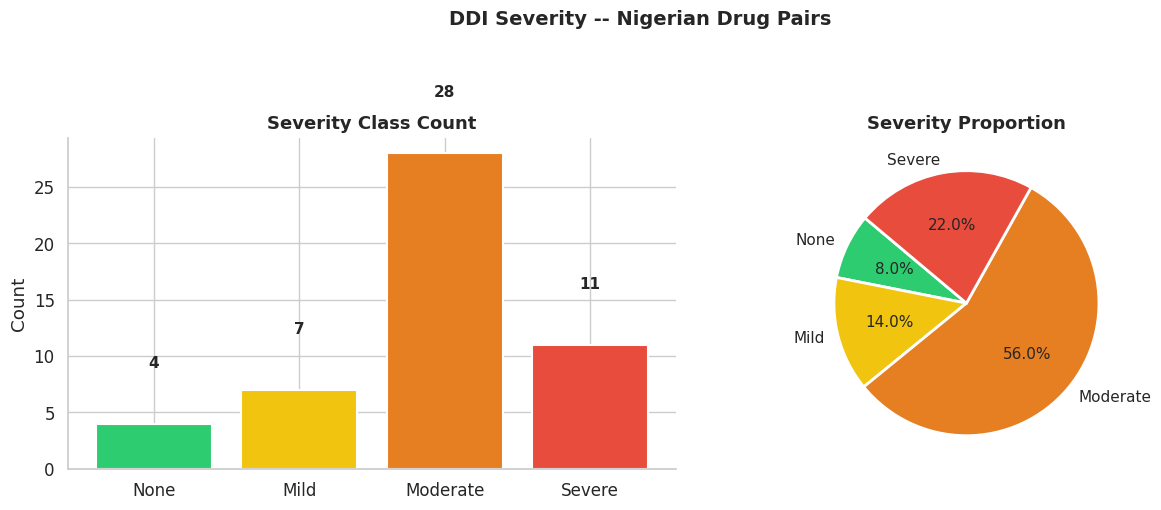

Imbalance ratio None:Severe = 0.4x -- SMOTE in Notebook 02


In [17]:
counts = final_df['severity_label'].value_counts().reindex(SEV_ORDER)
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
bars = ax1.bar(counts.index,counts.values,color=SEV_COLORS,edgecolor='white',linewidth=1.5)
for bar,n in zip(bars,counts.values):
    ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()+5,f'{n:,}',
             ha='center',fontsize=11,fontweight='bold')
ax1.set_title('Severity Class Count',fontsize=13,fontweight='bold')
ax1.set_ylabel('Count'); ax1.spines[['top','right']].set_visible(False)
ax2.pie(counts.values,labels=counts.index,colors=SEV_COLORS,autopct='%1.1f%%',
        startangle=140,wedgeprops=dict(linewidth=2,edgecolor='white'),textprops={'fontsize':11})
ax2.set_title('Severity Proportion',fontsize=13,fontweight='bold')
plt.suptitle('DDI Severity -- Nigerian Drug Pairs',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig('01_severity_distribution.png',dpi=150,bbox_inches='tight')
plt.show()
print(f'Imbalance ratio None:Severe = {counts["None"]/counts["Severe"]:.1f}x -- SMOTE in Notebook 02')

### 9.2 Drug Class vs Severity

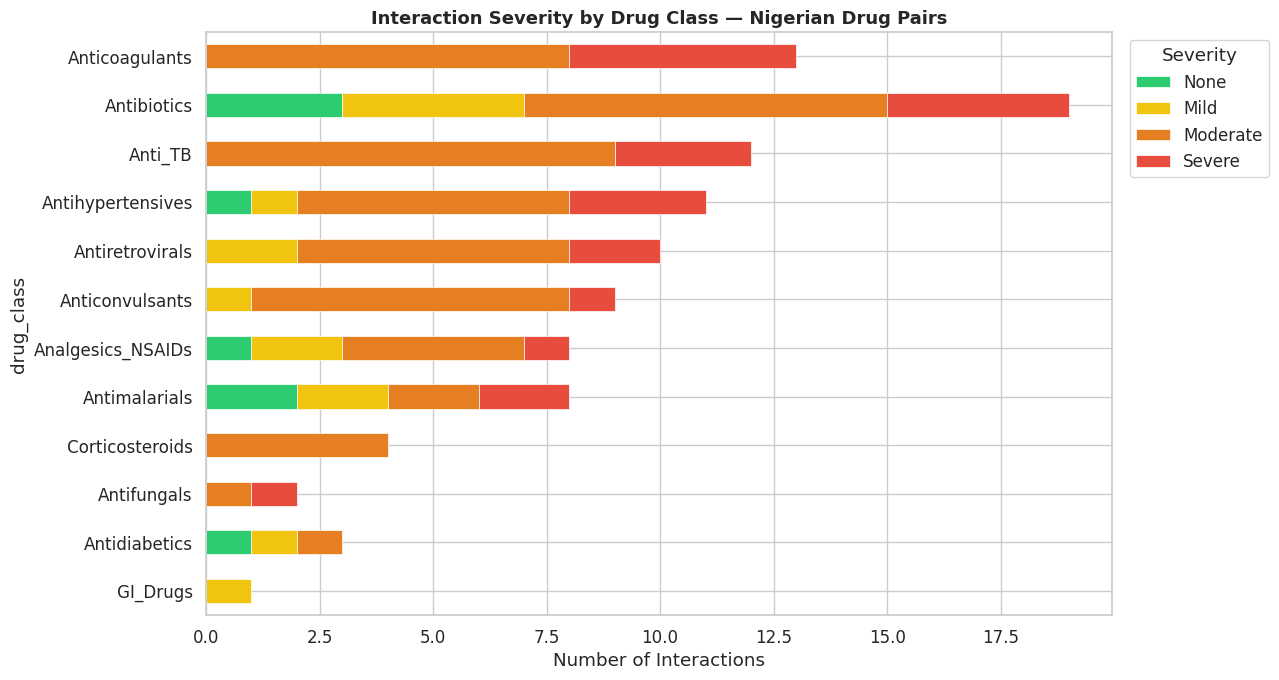

In [18]:
cs = pd.concat([
    final_df[['class_a','severity_label']].rename(columns={'class_a':'drug_class'}),
    final_df[['class_b','severity_label']].rename(columns={'class_b':'drug_class'})
]).dropna(subset=['drug_class'])

ct = pd.crosstab(cs['drug_class'], cs['severity_label']).reindex(columns=SEV_ORDER, fill_value=0)
ct = ct.assign(_s=ct['Severe']*3+ct['Moderate']*2).sort_values('_s').drop(columns='_s')

ct.plot(kind='barh', stacked=True, color=SEV_COLORS, figsize=(13,7),
        edgecolor='white', linewidth=0.5)
plt.title('Interaction Severity by Drug Class — Nigerian Drug Pairs', fontsize=13, fontweight='bold')
plt.xlabel('Number of Interactions')
plt.legend(title='Severity', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('02_class_severity.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Most Dangerous Drug Pairs

In [19]:
severe = (final_df[final_df['severity']==3]
          .assign(pair=lambda x:x['drug_a']+'  x  '+x['drug_b'])
          [['pair','class_a','class_b']].drop_duplicates().head(15).assign(count=1))
fig = px.bar(severe,y='pair',x='count',color='class_a',orientation='h',
             title='Severe DDI Pairs -- Nigerian Clinical Context',
             labels={'pair':'Drug Pair','count':'','class_a':'Class of Drug A'},
             color_discrete_sequence=px.colors.qualitative.Set2,height=520)
fig.update_layout(plot_bgcolor='white',xaxis=dict(showticklabels=False,showgrid=False))
fig.show()

### 9.4 CYP Enzyme Heatmap

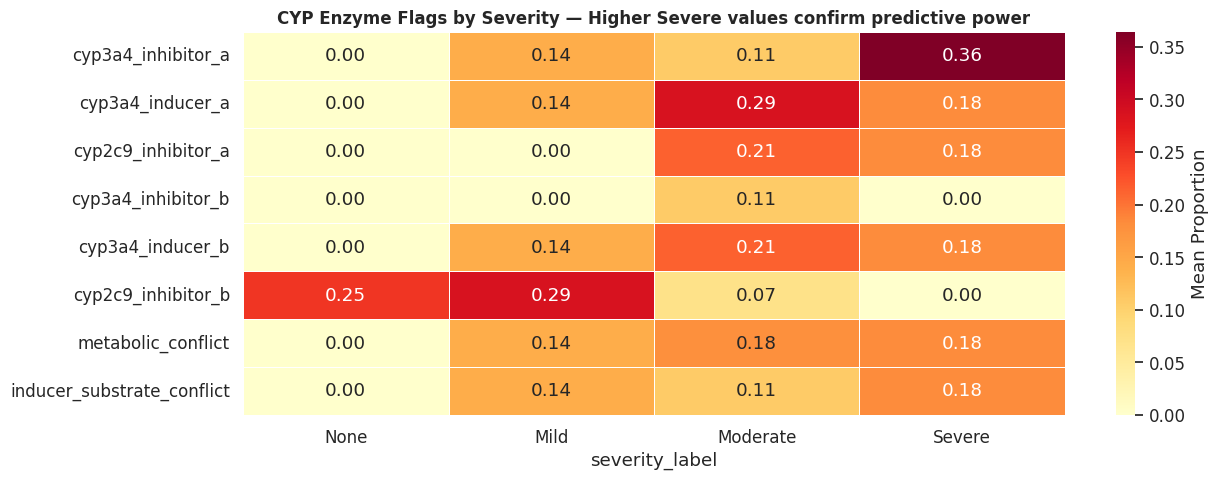

In [20]:
cyp_cols = ['cyp3a4_inhibitor_a','cyp3a4_inducer_a','cyp2c9_inhibitor_a',
            'cyp3a4_inhibitor_b','cyp3a4_inducer_b','cyp2c9_inhibitor_b',
            'metabolic_conflict','inducer_substrate_conflict']

cyp_by_sev = final_df.groupby('severity_label')[cyp_cols].mean().reindex(SEV_ORDER).round(3)
plt.figure(figsize=(13,5))
sns.heatmap(cyp_by_sev.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Mean Proportion'})
plt.title('CYP Enzyme Flags by Severity — Higher Severe values confirm predictive power',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03_cyp_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.5 Molecular Property Distributions

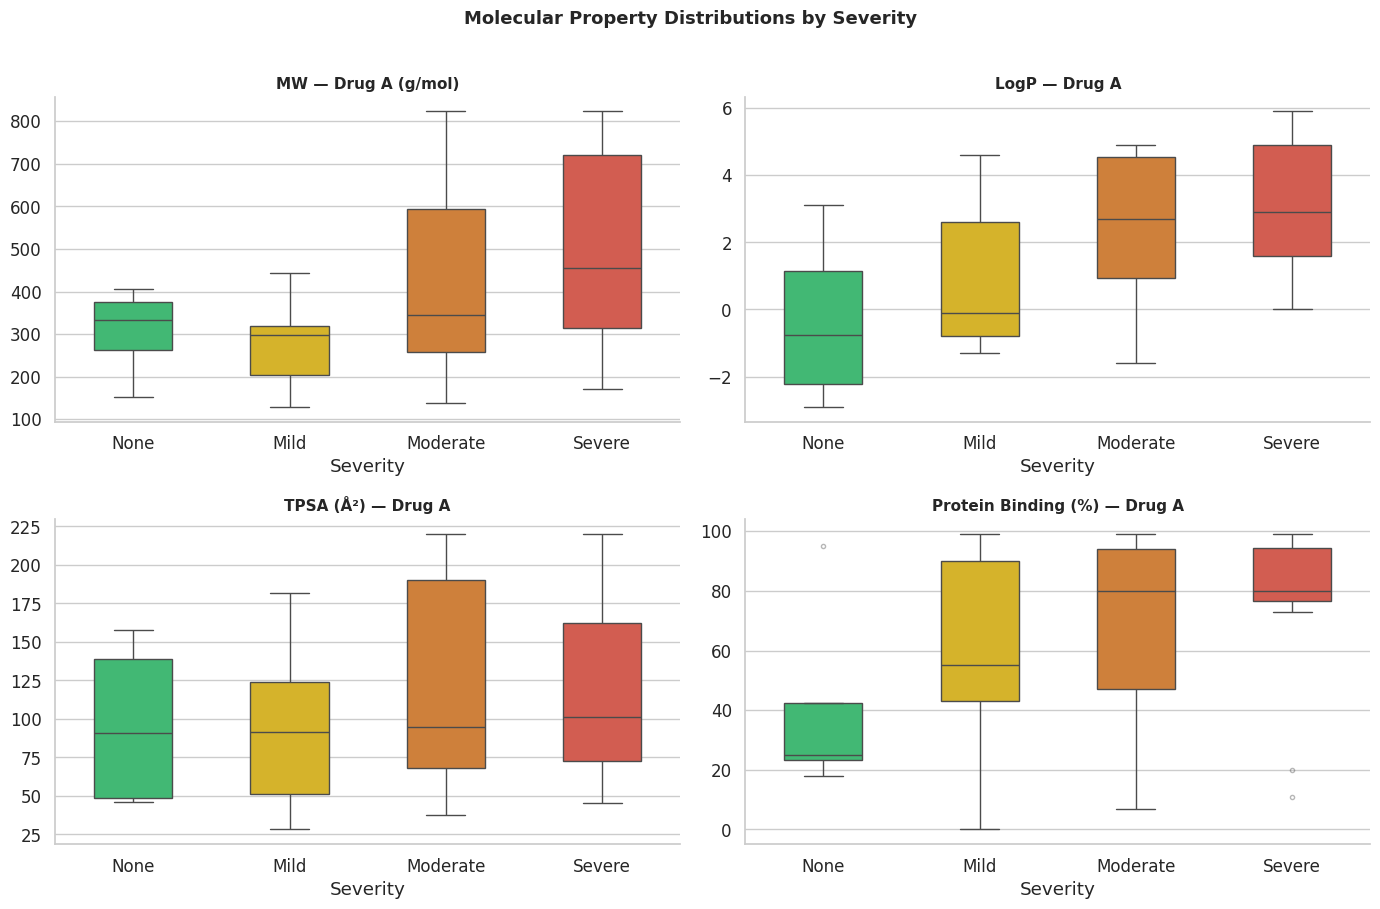

In [21]:
mol_feats = [('mw_a','MW — Drug A (g/mol)'),('logp_a','LogP — Drug A'),
             ('tpsa_a','TPSA (Å²) — Drug A'),('protein_binding_a','Protein Binding (%) — Drug A')]

fig, axes = plt.subplots(2, 2, figsize=(14,9))
for ax,(col,title) in zip(axes.flatten(), mol_feats):
    sns.boxplot(data=final_df.dropna(subset=[col]), x='severity_label', y=col,
                order=SEV_ORDER, palette=dict(zip(SEV_ORDER,SEV_COLORS)),
                width=0.5, flierprops=dict(marker='o',markersize=3,alpha=0.4), ax=ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Severity'); ax.set_ylabel('')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Molecular Property Distributions by Severity', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_molecular_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.6 Feature Correlation Heatmap

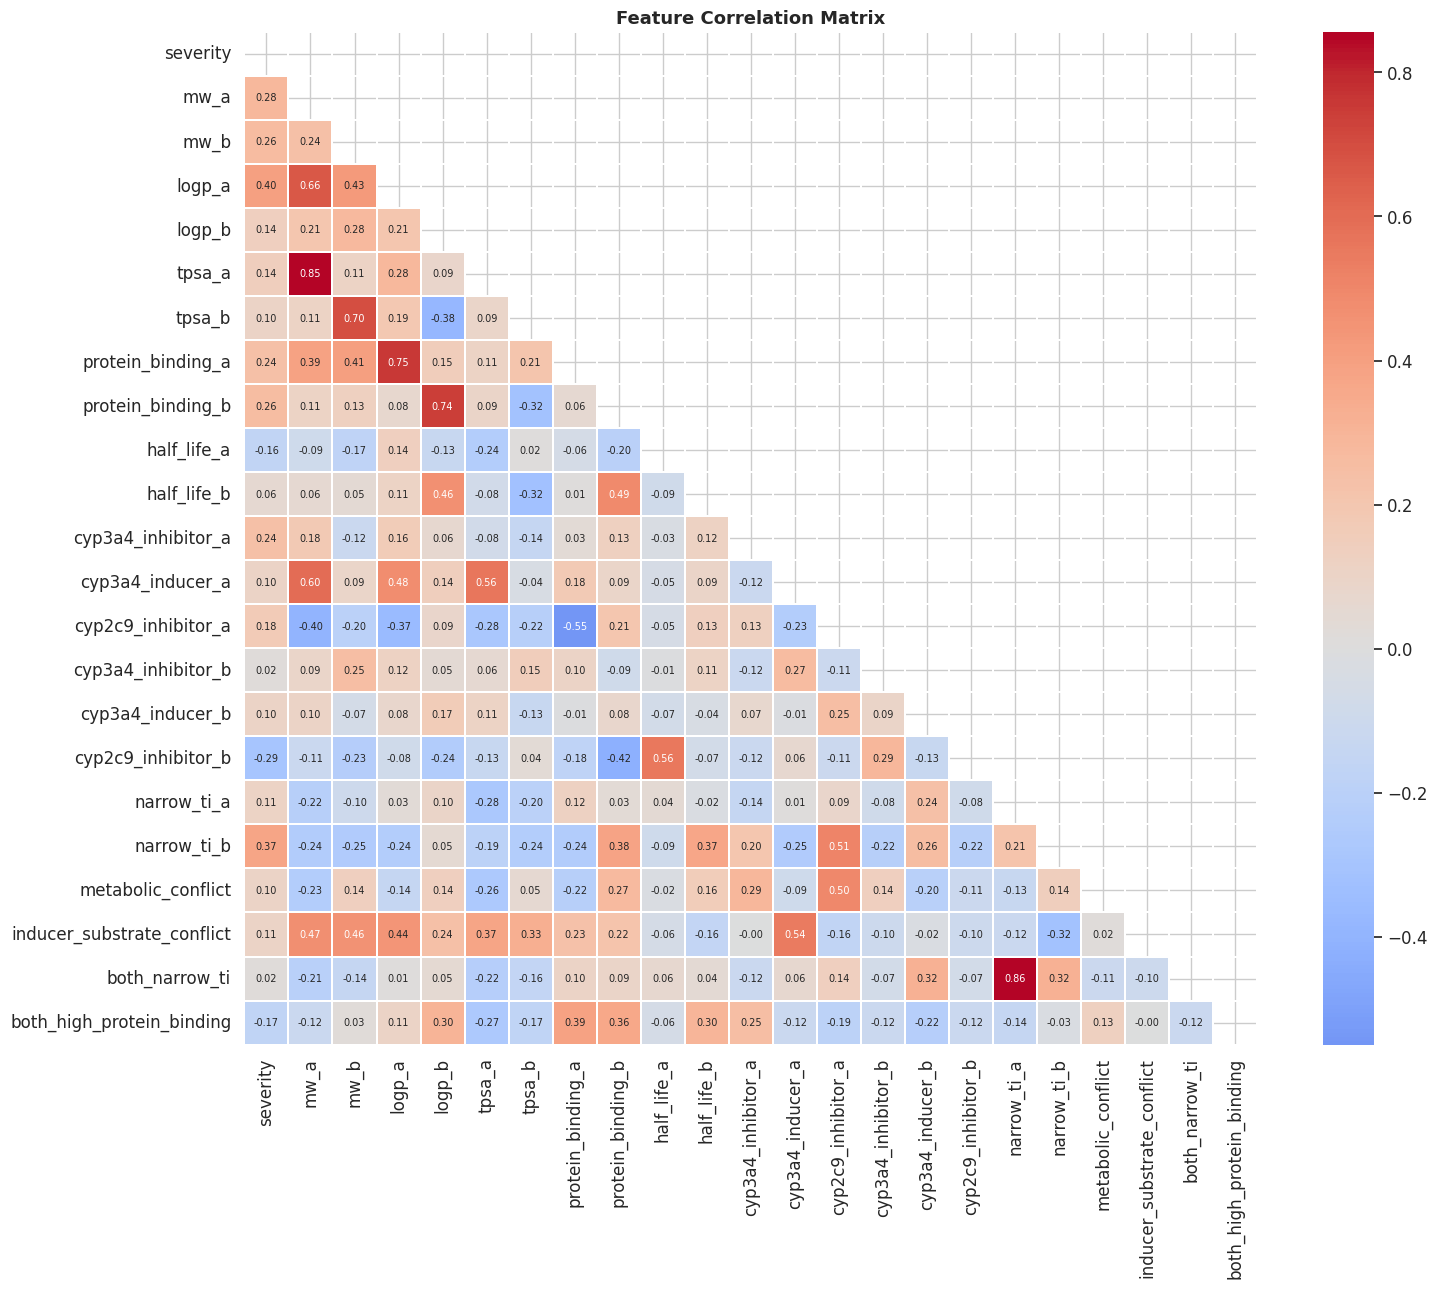


Top 10 features correlated with severity:
  logp_a                              +0.396  ███████
  narrow_ti_b                         +0.374  ███████
  cyp2c9_inhibitor_b                  -0.293  █████
  mw_a                                +0.283  █████
  mw_b                                +0.264  █████
  protein_binding_b                   +0.258  █████
  protein_binding_a                   +0.239  ████
  cyp3a4_inhibitor_a                  +0.238  ████
  cyp2c9_inhibitor_a                  +0.175  ███
  both_high_protein_binding           -0.169  ███


In [22]:
num_cols = ['severity','mw_a','mw_b','logp_a','logp_b','tpsa_a','tpsa_b',
            'protein_binding_a','protein_binding_b','half_life_a','half_life_b',
            'cyp3a4_inhibitor_a','cyp3a4_inducer_a','cyp2c9_inhibitor_a',
            'cyp3a4_inhibitor_b','cyp3a4_inducer_b','cyp2c9_inhibitor_b',
            'narrow_ti_a','narrow_ti_b','metabolic_conflict',
            'inducer_substrate_conflict','both_narrow_ti','both_high_protein_binding']

corr = final_df[num_cols].dropna().corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16,13))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', annot_kws={'size':7},
            cmap='coolwarm', center=0, square=True, linewidths=0.3, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

sev_corr = corr['severity'].drop('severity').sort_values(key=abs, ascending=False)
print('\nTop 10 features correlated with severity:')
for feat, val in sev_corr.head(10).items():
    print(f'  {feat:35s} {val:+.3f}  {"█"*int(abs(val)*20)}')

### 9.7 Nigeria Disease Area Profile

In [23]:
cp = final_df.copy()
cp['class_pair'] = cp.apply(
    lambda r: ' × '.join(sorted([str(r['class_a']), str(r['class_b'])])), axis=1)

pair_sev = cp.groupby(['class_pair','severity_label']).size().reset_index(name='count')
top12 = cp['class_pair'].value_counts().head(12).index.tolist()
pair_sev = pair_sev[pair_sev['class_pair'].isin(top12)]

fig = px.bar(pair_sev, x='count', y='class_pair', color='severity_label',
             orientation='h', barmode='stack',
             color_discrete_map=dict(zip(SEV_ORDER,SEV_COLORS)),
             category_orders={'severity_label':SEV_ORDER},
             title='Severity Profile by Drug Class Pairs — Nigerian Context',
             labels={'count':'Interactions','class_pair':'Class Pair','severity_label':'Severity'},
             height=560)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white',
                  yaxis=dict(categoryorder='total ascending'),
                  legend=dict(orientation='h', y=1.02, x=1, xanchor='right'))
fig.show()
print('\n🇳🇬 Anti_TB × Antiretrovirals = Rifampicin-ARV — most critical DDI scenario in Nigeria')


🇳🇬 Anti_TB × Antiretrovirals = Rifampicin-ARV — most critical DDI scenario in Nigeria


In [25]:
print('='*55)
print('  DATASET SUMMARY')
print('='*55)
print(f'  Drug pairs          : {len(final_df):,}')
print(f'  Unique drugs        : {len(active_drugs)}')
print(f'  Feature columns     : {final_df.shape[1]-5}')
print(f'  NAFDAC scraped drugs: {len(nafdac_scraped):,}')
print(f'  Therapeutic classes : {len(NIGERIAN_DRUG_LIST)}')
print()
for label in SEV_ORDER:
    n = (final_df['severity_label']==label).sum()
    pct = n/len(final_df)*100
    print(f'  {label:10s}: {n:5,} ({pct:5.1f}%)  {chr(9608)*int(pct/2)}')
print('='*55)

  DATASET SUMMARY
  Drug pairs          : 50
  Unique drugs        : 46
  Feature columns     : 32
  NAFDAC scraped drugs: 1,775
  Therapeutic classes : 12

  None      :     4 (  8.0%)  ████
  Mild      :     7 ( 14.0%)  ███████
  Moderate  :    28 ( 56.0%)  ████████████████████████████
  Severe    :    11 ( 22.0%)  ███████████


---
## 10. Save to Google Drive

In [27]:
os.makedirs(SAVE_FOLDER, exist_ok=True)

OUT_FEATURES = os.path.join(SAVE_FOLDER, 'ddi_nigeria_features.csv')
OUT_PUBCHEM  = os.path.join(SAVE_FOLDER, 'pubchem_properties.csv')

final_df.to_csv(OUT_FEATURES, index=False)
pubchem_df.to_csv(OUT_PUBCHEM, index=False)

print('✅ Saved to Google Drive:')
print(f'   {OUT_FEATURES}  ({len(final_df):,} rows)')
print(f'   {OUT_PUBCHEM}   ({len(pubchem_df):,} rows)')

print('Input → ddi_nigeria_features.csv')

✅ Saved to Google Drive:
   /content/drive/MyDrive/DDI project /ddi_nigeria_features.csv  (50 rows)
   /content/drive/MyDrive/DDI project /pubchem_properties.csv   (46 rows)
Input → ddi_nigeria_features.csv
